# Task 4: LoRA Fine-Tuning — Granulometry Classification

- **Approach A**: Standard LoRA — 18 direct labeled examples
- **Approach B**: SEAL-inspired LoRA — ~144 augmented examples via GPT-4.1

Memory strategy: one LoRA at a time. Train A → save → free → Train B → save → free → Eval from disk.

## Setup

In [7]:
import os, json, re, time, torch, gc, random, base64
import numpy as np
from PIL import Image
from collections import defaultdict, Counter
import matplotlib.pyplot as plt

for i in range(torch.cuda.device_count()):
    print(f'GPU {i}: {torch.cuda.get_device_name(i)} — {torch.cuda.get_device_properties(i).total_memory/1e9:.1f} GB')


GPU 0: Tesla V100-PCIE-16GB — 16.9 GB
GPU 1: Tesla V100-PCIE-16GB — 16.9 GB


## Config

In [8]:
TRAIN_DIR = '../../datasets/granulometry/train'
TEST_DIR = '../../datasets/granulometry/test'
TRAIN_MANIFEST = '../../datasets/granulometry/train_manifest.json'
TEST_MANIFEST = '../../datasets/granulometry/test_manifest.json'
MODEL_ID = 'Qwen/Qwen2.5-VL-3B-Instruct'
ORIGINAL_GSD = 8.0
MAX_DIM = 800  # consistent for train and eval — GSD scales accordingly
SEED = 42
IMAGES_PER_CLASS = 1

LORA_R = 16
LORA_ALPHA = 32
LORA_DROPOUT = 0.05
LORA_TARGETS = ['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj']
EPOCHS = 40
LR = 2e-5
BATCH_SIZE = 1
GRAD_ACCUM = 4

AZURE_ENDPOINT = 'https://ether-openai.openai.azure.com/'
DEPLOYMENT = 'gpt-4.1'
API_VERSION = '2024-12-01-preview'
os.environ['AZURE_OPENAI_API_KEY'] = '871a30b46ebf4297a8938ff5fca23646'


## Step 1: Select Training Images

In [9]:
random.seed(SEED)
with open(TRAIN_MANIFEST) as f:
    train_manifest = json.load(f)
by_class = defaultdict(list)
for e in train_manifest: by_class[e['class']].append(e)
selected = []
for cls in sorted(by_class):
    random.shuffle(by_class[cls])
    selected.extend(by_class[cls][:IMAGES_PER_CLASS])
print(f'{len(selected)} training images selected')
for e in selected: print(f'  {e["class"]}: {e["image"]}')


9 training images selected
  A16: S2_A16_2.11.9.JPG
  A32: S1_A32_IMG_5567.JPG
  A8: S1_A8_IMG_5620.JPG
  B16: S1_B16_IMG_7763.JPG
  B32: S2_B32_3.4.35.JPG
  B8: S1_B8_IMG_5791.JPG
  C16: S1_C16_IMG_7678.JPG
  C32: S2_C32_3.1.42.JPG
  C8: S2_C8_1.1.9.JPG


## Step 2A: Direct Training Data (18 examples)

In [10]:
DIRECT_PROMPT = (
    'Classify this concrete aggregate photo. GSD = {gsd:.1f} px/mm.\n'
    'Grading (DIN 1045): coarse = gaps empty, uniform; medium = gaps partially filled; '
    'fine = gaps completely filled, dense packed.\n'
    'Respond with ONLY JSON: {{"max_particle_size_mm": <8|16|32>, "grading": "<coarse|medium|fine>"}}'
)
direct_data = []
for entry in selected:
    img_path = os.path.join(TRAIN_DIR, entry['image'])
    gt = json.dumps({'max_particle_size_mm': entry['max_particle_size_mm'], 'grading': entry['grading']})
    direct_data.append({'messages': [
        {'role': 'user', 'content': [{'type': 'image', 'image': img_path}, {'type': 'text', 'text': DIRECT_PROMPT.format(gsd=ORIGINAL_GSD)}]},
        {'role': 'assistant', 'content': gt},
    ]})
with open('training_data_direct.jsonl', 'w') as f:
    for r in direct_data: f.write(json.dumps(r) + '\n')
print(f'Saved {len(direct_data)} examples to training_data_direct.jsonl')

# Preview
print(f'\n--- Sample (Approach A) ---')
s = direct_data[0]
print(f'Image:    {s["messages"][0]["content"][0]["image"]}')
print(f'Prompt:   {s["messages"][0]["content"][1]["text"][:150]}...')
print(f'Response: {s["messages"][1]["content"]}')


Saved 9 examples to training_data_direct.jsonl

--- Sample (Approach A) ---
Image:    ../../datasets/granulometry/train/S2_A16_2.11.9.JPG
Prompt:   Classify this concrete aggregate photo. GSD = 8.0 px/mm.
Grading (DIN 1045): coarse = gaps empty, uniform; medium = gaps partially filled; fine = gaps...
Response: {"max_particle_size_mm": 16, "grading": "coarse"}


## Step 2B: SEAL-Augmented Data (~144 examples via GPT-4.1)

In [11]:
from openai import AzureOpenAI
gpt_client = AzureOpenAI(azure_endpoint=AZURE_ENDPOINT, api_key=os.environ.get('AZURE_OPENAI_API_KEY',''), api_version=API_VERSION)

GRADING_DEFS = '''DIN 1045 grading curves:
COARSE (A): particles concentrated near max size. Gaps between stones are EMPTY. Uniform look.
MEDIUM (B): balanced mix. Gaps PARTIALLY filled by smaller particles.
FINE (C): wide size range. Gaps COMPLETELY filled with small particles. Dense, packed.'''

TASK_INSTRUCTION = 'Classify this concrete aggregate. Respond with JSON: {"max_particle_size_mm": 8, 16, or 32, "grading": "coarse, medium, or fine"}'

GT = {
    'A8': (8,'coarse'), 'A16': (16,'coarse'), 'A32': (32,'coarse'),
    'B8': (8,'medium'), 'B16': (16,'medium'), 'B32': (32,'medium'),
    'C8': (8,'fine'),   'C16': (16,'fine'),   'C32': (32,'fine'),
}

STYLES = [
    "Write a short direct prompt asking to classify this concrete aggregate image.",
    "Write a prompt that describes the visible particle sizes and asks for classification.",
    "Write a prompt that describes the gaps between the largest stones — are they empty, partially filled, or completely filled — and asks for classification.",
    "Write a prompt comparing this to DIN 1045 grading curves A, B, C and asking which one it matches.",
    "Write a prompt that estimates the largest stone size and asks for the max particle size classification.",
    "Write a prompt that describes the packing density and texture, then asks for grading classification.",
    "Write a prompt explaining why this does NOT look like the other two gradings, then asks for the correct one.",
    "Write a very short minimal prompt — just a few words.",
]

def encode_image(path):
    with open(path, 'rb') as f: return base64.b64encode(f.read()).decode('utf-8')

print(f'GPT-4.1 ready. {len(STYLES)} styles x {len(selected)} images = {len(STYLES)*len(selected)} API calls')


GPT-4.1 ready. 8 styles x 9 images = 72 API calls


In [12]:
if os.path.exists('training_data_augmented.jsonl'):
    os.remove('training_data_augmented.jsonl')
    print('Deleted old augmented data')

augmented_data = []
for entry in selected:
    img_path = os.path.join(TRAIN_DIR, entry['image'])
    if not os.path.exists(img_path): continue
    cls = entry['class']
    gt_size, gt_grading = GT[cls]
    gt_json = json.dumps({"max_particle_size_mm": gt_size, "grading": gt_grading})
    img_b64 = encode_image(img_path)
    
    print(f'  {cls}: {entry["image"]}', end='', flush=True)
    for style in STYLES:
        instruction = f'''{style}
This image shows {gt_grading} grading with max particle size {gt_size}mm.
{GRADING_DEFS}
Reply with ONLY the prompt text. No JSON, no labels, just the prompt a user would type.'''
        try:
            resp = gpt_client.chat.completions.create(
                model=DEPLOYMENT, max_tokens=256, temperature=0.7,
                messages=[{'role':'user','content':[
                    {'type':'image_url','image_url':{'url':f'data:image/jpeg;base64,{img_b64}'}},
                    {'type':'text','text':instruction}]}])
            prompt_text = resp.choices[0].message.content.strip()
            # Remove any quotes GPT-4.1 might wrap around the prompt
            prompt_text = prompt_text.strip('"').strip("'")
            # Append standard task instruction
            full_prompt = prompt_text + '\n' + TASK_INSTRUCTION
            
            augmented_data.append({'messages':[
                {'role':'user','content':[{'type':'image','image':img_path},{'type':'text','text':full_prompt}]},
                {'role':'assistant','content': gt_json}]})
            print('.', end='', flush=True)
        except Exception as e:
            print('X', end='', flush=True)
        time.sleep(0.3)
    print(f' done')

with open('training_data_augmented.jsonl', 'w') as f:
    for r in augmented_data:
        f.write(json.dumps(r) + '\n')
print(f'\nSaved {len(augmented_data)} examples')
print(f'All responses are GT JSON — zero format issues guaranteed')

# Preview
if augmented_data:
    print(f'\n--- Sample ---')
    s = augmented_data[0]
    print(f'Prompt: {s["messages"][0]["content"][1]["text"]}')
    print(f'Response: {s["messages"][1]["content"]}')


  A16: S2_A16_2.11.9.JPG........ done
  A32: S1_A32_IMG_5567.JPG........ done
  A8: S1_A8_IMG_5620.JPG........ done
  B16: S1_B16_IMG_7763.JPG........ done
  B32: S2_B32_3.4.35.JPG........ done
  B8: S1_B8_IMG_5791.JPG........ done
  C16: S1_C16_IMG_7678.JPG........ done
  C32: S2_C32_3.1.42.JPG........ done
  C8: S2_C8_1.1.9.JPG........ done

Saved 72 examples
All responses are GT JSON — zero format issues guaranteed

--- Sample ---
Prompt: Classify the aggregate in this image according to DIN 1045 grading curves (COARSE, MEDIUM, FINE). The maximum particle size is 16mm.
Classify this concrete aggregate. Respond with JSON: {"max_particle_size_mm": 8, 16, or 32, "grading": "coarse, medium, or fine"}
Response: {"max_particle_size_mm": 16, "grading": "coarse"}


In [14]:
if augmented_data:
    print('--- Sample 1 (Approach B) ---')
    s = augmented_data[0]
    print(f'Prompt:   {s["messages"][0]["content"][1]["text"][:200]}')
    print(f'Response: {s["messages"][1]}')
    if len(augmented_data) > 2:
        print(f'\n--- Sample 2 (different style) ---')
        s2 = augmented_data[2]
        print(f'Prompt:   {s2["messages"][0]["content"][1]["text"][:200]}')
        print(f'Response: {s2["messages"][1]}')


--- Sample 1 (Approach B) ---
Prompt:   Classify the aggregate in this image according to DIN 1045 grading curves (COARSE, MEDIUM, FINE). The maximum particle size is 16mm.
Classify this concrete aggregate. Respond with JSON: {"max_particle
Response: {'role': 'assistant', 'content': '{"max_particle_size_mm": 16, "grading": "coarse"}'}

--- Sample 2 (different style) ---
Prompt:   Examine the gaps between the largest stones in this image. Are these gaps mostly empty, partially filled with smaller particles, or completely filled so that hardly any gaps remain? Classify the gradi
Response: {'role': 'assistant', 'content': '{"max_particle_size_mm": 16, "grading": "coarse"}'}


## Step 3: Load Base Model (BF16)

In [10]:
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor
from peft import LoraConfig, get_peft_model, PeftModel
from transformers import get_cosine_schedule_with_warmup
from torch.utils.data import Dataset

processor = AutoProcessor.from_pretrained(
    MODEL_ID,
    min_pixels=256 * 28 * 28,
    max_pixels=512 * 28 * 28,  # ~512 visual tokens max — fits in VRAM
)
base_model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID, device_map='auto', torch_dtype=torch.bfloat16)
base_model.enable_input_require_grads()

lora_config = LoraConfig(r=LORA_R, lora_alpha=LORA_ALPHA, lora_dropout=LORA_DROPOUT,
    target_modules=LORA_TARGETS, task_type='CAUSAL_LM', bias='none')

print(f'Base model loaded (BF16).')
for i in range(torch.cuda.device_count()):
    print(f'  GPU {i}: {torch.cuda.memory_allocated(i)/1e9:.1f} GB')


/anaconda/envs/azureml_py38/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-13 08:01:53.525840: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-13 08:01:53.525891: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-13 08:01:53.527693: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-13 08:01:53.537606: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary

Base model loaded (BF16).
  GPU 0: 4.0 GB
  GPU 1: 3.6 GB


## Step 4: Training
Trains one LoRA at a time. After training, saves adapter and frees all training memory.

In [11]:
class GranulometryDataset(Dataset):
    def __init__(self, jsonl_path, processor):
        with open(jsonl_path) as f:
            self.data = [json.loads(line) for line in f]
        self.processor = processor
    def __len__(self): return len(self.data)
    def __getitem__(self, idx):
        entry = self.data[idx]
        msgs = entry['messages']
        user_content = msgs[0]['content']
        img_path = next((c['image'] for c in user_content if c['type']=='image'), None)
        user_text = next((c['text'] for c in user_content if c['type']=='text'), '')
        assistant_text = msgs[1]['content']
        if not isinstance(assistant_text, str):
            assistant_text = json.dumps(assistant_text)
        image = Image.open(img_path).convert('RGB') if img_path else None
        chat = [{'role':'user','content':[{'type':'image','image':image},{'type':'text','text':user_text}]},
                {'role':'assistant','content':[{'type':'text','text':assistant_text}]}]
        text = self.processor.apply_chat_template(chat, tokenize=False, add_generation_prompt=False)
        inputs = self.processor(text=[text], images=[image], return_tensors='pt', padding=True)
        input_ids = inputs['input_ids'].squeeze(0)
        labels = input_ids.clone()
        # Mask user tokens
        ast_tokens = self.processor.tokenizer.encode(assistant_text, add_special_tokens=False)
        if len(ast_tokens) < len(labels): labels[:-len(ast_tokens)] = -100
        if image: image.close()
        return {'input_ids': input_ids, 'attention_mask': inputs['attention_mask'].squeeze(0),
                'labels': labels, 'pixel_values': inputs.get('pixel_values', None),
                'image_grid_thw': inputs.get('image_grid_thw', None)}


def train_lora(base_model, processor, data_path, output_dir, lora_config, epochs=EPOCHS, lr=LR):
    """Apply LoRA → train → save adapter → unload LoRA → free memory."""
    model = get_peft_model(base_model, lora_config)
    model.gradient_checkpointing_enable()
    model.print_trainable_parameters()
    dataset = GranulometryDataset(data_path, processor)
    print(f'Training: {len(dataset)} examples, {epochs} epochs, effective batch={GRAD_ACCUM}')
    
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    total_steps = max(len(dataset) * epochs // GRAD_ACCUM, 1)
    scheduler = get_cosine_schedule_with_warmup(optimizer, int(total_steps*0.1), total_steps)
    
    model.train()
    losses = []
    for epoch in range(epochs):
        epoch_loss = 0
        for i in range(len(dataset)):
            batch = dataset[i]
            ids = batch['input_ids'].unsqueeze(0).to(model.device)
            mask = batch['attention_mask'].unsqueeze(0).to(model.device)
            lab = batch['labels'].unsqueeze(0).to(model.device)
            kw = {'input_ids': ids, 'attention_mask': mask, 'labels': lab}
            if batch.get('pixel_values') is not None: kw['pixel_values'] = batch['pixel_values'].to(model.device)
            if batch.get('image_grid_thw') is not None: kw['image_grid_thw'] = batch['image_grid_thw'].to(model.device)
            out = model(**kw)
            loss = out.loss / GRAD_ACCUM
            loss.backward()
            epoch_loss += loss.item() * GRAD_ACCUM
            if (i+1) % GRAD_ACCUM == 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step(); scheduler.step(); optimizer.zero_grad()
            del ids, mask, lab, out, loss; torch.cuda.empty_cache()
        avg = epoch_loss / len(dataset)
        losses.append(avg)
        if (epoch+1) % 5 == 0 or epoch == 0:
            print(f'  Epoch {epoch+1}/{epochs} — loss: {avg:.4f} — lr: {scheduler.get_last_lr()[0]:.2e}')
    
    # Save adapter
    os.makedirs(output_dir, exist_ok=True)
    model.save_pretrained(output_dir)
    print(f'Adapter saved to {output_dir}/')
    
    # Unload LoRA, free training memory
    model.unload()
    del model, optimizer, scheduler, dataset
    gc.collect(); torch.cuda.empty_cache()
    print(f'Memory freed. GPU 0: {torch.cuda.memory_allocated(0)/1e9:.1f} GB')
    return losses

print('Training function ready.')


Training function ready.


### Step 4A: Train Approach A (18 direct examples)

=== Approach A: Standard LoRA ===


/anaconda/envs/azureml_py38/lib/python3.10/site-packages/peft/mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/anaconda/envs/azureml_py38/lib/python3.10/site-packages/peft/tuners/tuners_utils.py:285: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


trainable params: 37,152,768 || all params: 3,791,775,744 || trainable%: 0.9798
Training: 18 examples, 40 epochs, effective batch=4
  Epoch 1/40 — loss: 0.2148 — lr: 4.44e-06
  Epoch 5/40 — loss: 0.1490 — lr: 2.00e-05
  Epoch 10/40 — loss: 0.1210 — lr: 1.91e-05
  Epoch 15/40 — loss: 0.0822 — lr: 1.69e-05
  Epoch 20/40 — loss: 0.0319 — lr: 1.36e-05
  Epoch 25/40 — loss: 0.0171 — lr: 9.81e-06
  Epoch 30/40 — loss: 0.0129 — lr: 6.04e-06
  Epoch 35/40 — loss: 0.0125 — lr: 2.86e-06
  Epoch 40/40 — loss: 0.0078 — lr: 7.43e-07
Adapter saved to lora_direct/
Memory freed. GPU 0: 4.6 GB


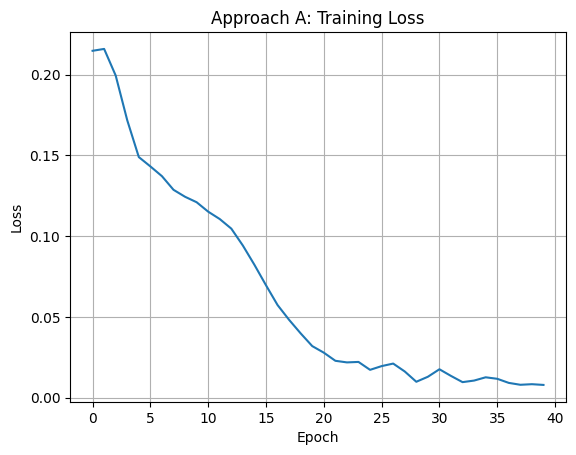

In [14]:
print('=== Approach A: Standard LoRA ===')
losses_a = train_lora(base_model, processor, 'training_data_direct.jsonl', 'lora_direct', lora_config)
plt.plot(losses_a); plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('Approach A: Training Loss'); plt.grid(True); plt.show()


### Step 4B: Train Approach B (SEAL-augmented)

=== Approach B: SEAL-Augmented LoRA ===
trainable params: 37,152,768 || all params: 3,791,775,744 || trainable%: 0.9798
Training: 144 examples, 40 epochs, effective batch=4
  Epoch 1/40 — loss: 2.4514 — lr: 5.00e-06
  Epoch 5/40 — loss: 0.7567 — lr: 2.00e-05
  Epoch 10/40 — loss: 0.3706 — lr: 1.87e-05
  Epoch 15/40 — loss: 0.0928 — lr: 1.57e-05
  Epoch 20/40 — loss: 0.0150 — lr: 1.17e-05
  Epoch 25/40 — loss: 0.0014 — lr: 7.41e-06
  Epoch 30/40 — loss: 0.0008 — lr: 3.57e-06
  Epoch 35/40 — loss: 0.0006 — lr: 9.37e-07
  Epoch 40/40 — loss: 0.0006 — lr: 0.00e+00
Adapter saved to lora_augmented/
Memory freed. GPU 0: 4.6 GB


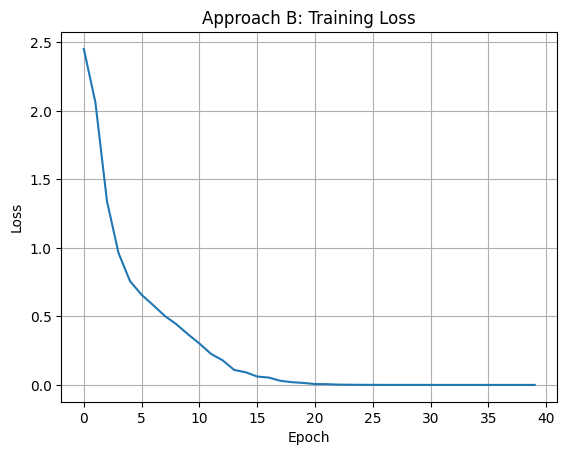

In [15]:
print('=== Approach B: SEAL-Augmented LoRA ===')
losses_b = train_lora(base_model, processor, 'training_data_augmented.jsonl', 'lora_augmented', lora_config)
plt.plot(losses_b); plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('Approach B: Training Loss'); plt.grid(True); plt.show()


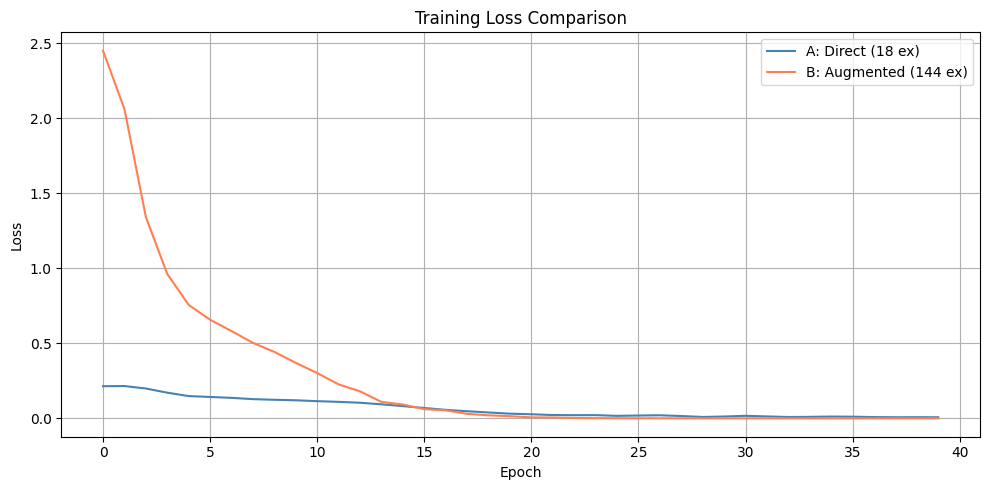

In [19]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(losses_a, label=f'A: Direct ({len(direct_data)} ex)', color='steelblue')
ax.plot(losses_b, label=f'B: Augmented ({len(augmented_data)} ex)', color='coral')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.set_title('Training Loss Comparison')
ax.legend(); ax.grid(True); plt.tight_layout(); plt.show()


## Step 5: Evaluate
Load adapters from disk one at a time to save memory.

In [30]:
EVAL_PROMPT = '''Classify this concrete aggregate photo. GSD = {gsd:.1f} px/mm.
Grading (DIN 1045): coarse = gaps empty, uniform; medium = gaps partially filled; fine = gaps completely filled, dense.
Respond with ONLY JSON: {{"max_particle_size_mm": <8|16|32>, "grading": "<coarse|medium|fine>"}}'''

def parse_response(raw):
    if not raw: return None
    raw = raw.replace('<', '').replace('>', '')
    raw = re.sub(r'```json\s*','',raw); raw = re.sub(r'```\s*','',raw).strip()
    try:
        obj = json.loads(raw)
        if isinstance(obj, dict): return obj
    except: pass
    m = re.search(r'\{.*\}', raw, re.DOTALL)
    if m:
        try: return json.loads(m.group())
        except: pass
    sm = re.search(r'"max_particle_size_mm"\s*:\s*(\d+)', raw)
    gm = re.search(r'"grading"\s*:\s*"(\w+)"', raw)
    if sm and gm: return {'max_particle_size_mm': int(sm.group(1)), 'grading': gm.group(1)}
    return None

def run_eval(model, processor, manifest):
    model.eval()
    results=[]; cs=0; cg=0; vj=0; tt=0
    for i, entry in enumerate(manifest):
        img_path = os.path.join(TEST_DIR, entry['image'])
        if not os.path.exists(img_path): continue
        image = Image.open(img_path).convert('RGB')
        scale = min(MAX_DIM/max(image.size), 1.0)
        if scale < 1.0: image = image.resize((int(image.width*scale),int(image.height*scale)), Image.Resampling.LANCZOS)
        gsd = ORIGINAL_GSD * scale
        msgs = [{'role':'user','content':[{'type':'image','image':image},{'type':'text','text':EVAL_PROMPT.format(gsd=gsd)}]}]
        text = processor.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
        inputs = processor(text=[text], images=[image], return_tensors='pt', padding=True).to(model.device)
        t=time.time()
        with torch.no_grad(): ids = model.generate(**inputs, max_new_tokens=128, temperature=0.1, do_sample=True)
        elapsed=time.time()-t; tt+=elapsed
        out = processor.batch_decode(ids[:,inputs.input_ids.shape[1]:], skip_special_tokens=True)[0].strip()
        del inputs, ids; image.close(); torch.cuda.empty_cache()
        parsed = parse_response(out)
        gs=entry['max_particle_size_mm']; gg=entry['grading']; so=False; go=False
        if parsed:
            vj+=1; ps=parsed.get('max_particle_size_mm')
            if isinstance(ps,str): ps=int(ps) if ps.isdigit() else None
            if ps==gs: so=True; cs+=1
            if parsed.get('grading','').lower()==gg: go=True; cg+=1
        results.append({'image':entry['image'],'class':entry['class'],'gt_size':gs,'gt_grading':gg,
            'predicted':parsed,'raw':out,'size_correct':so,'grading_correct':go,'valid_json':parsed is not None,'time_s':round(elapsed,2)})
        if (i+1)%20==0:
            n=i+1; print(f'  [{n}/{len(manifest)}] Size:{cs}/{n}({cs/n*100:.0f}%) Grade:{cg}/{n}({cg/n*100:.0f}%)')
    return results, cs, cg, vj, tt

def eval_adapter(base_model, processor, adapter_path, manifest, label):
    """Load adapter from disk, eval, unload, free memory."""
    print(f'\nLoading {adapter_path}...')
    model = PeftModel.from_pretrained(base_model, adapter_path)
    results, cs, cg, vj, tt = run_eval(model, processor, manifest)
    model.unload()
    del model; gc.collect(); torch.cuda.empty_cache()
    print(f'Unloaded. GPU 0: {torch.cuda.memory_allocated(0)/1e9:.1f} GB')
    return results, cs, cg, vj, tt

with open(TEST_MANIFEST) as f: test_manifest = json.load(f)
print(f'Test set: {len(test_manifest)} images')


Test set: 108 images


### Quick Eval (9 images — 1 per class)

In [31]:
quick_classes = sorted(set(e['class'] for e in test_manifest))
quick_manifest = [next(e for e in test_manifest if e['class']==cls) for cls in quick_classes]

for label, adapter in [('A: Direct', 'lora_direct'), ('B: Augmented', 'lora_augmented')]:
    print(f'\n{"="*50}')
    print(f'{label} — Quick eval (9 images)')
    print(f'{"="*50}')
    r, cs, cg, vj, tt = eval_adapter(base_model, processor, adapter, quick_manifest, label)
    n = len(r)
    print(f'Size: {cs}/{n} ({cs/n*100:.0f}%) | Grading: {cg}/{n} ({cg/n*100:.0f}%)')
    for x in r:
        p = x['predicted']
        ps = p.get('max_particle_size_mm','?') if p else '?'
        pg = p.get('grading','?') if p else '?'
        sv = '✓' if x['size_correct'] else '✗'
        gv = '✓' if x['grading_correct'] else '✗'
        print(f'  {x["class"]:>3} GT:{x["gt_size"]}mm/{x["gt_grading"]} Pred:{ps}mm/{pg} Size{sv} Grade{gv}')



A: Direct — Quick eval (9 images)

Loading lora_direct...
Unloaded. GPU 0: 4.6 GB
Size: 8/9 (89%) | Grading: 6/9 (67%)
  A16 GT:16mm/coarse Pred:16mm/coarse Size✓ Grade✓
  A32 GT:32mm/coarse Pred:32mm/medium Size✓ Grade✗
   A8 GT:8mm/coarse Pred:8mm/coarse Size✓ Grade✓
  B16 GT:16mm/medium Pred:16mm/medium Size✓ Grade✓
  B32 GT:32mm/medium Pred:32mm/fine Size✓ Grade✗
   B8 GT:8mm/medium Pred:8mm/fine Size✓ Grade✗
  C16 GT:16mm/fine Pred:16mm/fine Size✓ Grade✓
  C32 GT:32mm/fine Pred:16mm/fine Size✗ Grade✓
   C8 GT:8mm/fine Pred:8mm/fine Size✓ Grade✓

B: Augmented — Quick eval (9 images)

Loading lora_augmented...
Unloaded. GPU 0: 4.6 GB
Size: 6/9 (67%) | Grading: 3/9 (33%)
  A16 GT:16mm/coarse Pred:16mm/coarse Size✓ Grade✓
  A32 GT:32mm/coarse Pred:32mm/coarse Size✓ Grade✓
   A8 GT:8mm/coarse Pred:8mm/coarse Size✓ Grade✓
  B16 GT:16mm/medium Pred:16mm/coarse Size✓ Grade✗
  B32 GT:32mm/medium Pred:32mm/coarse Size✓ Grade✗
   B8 GT:8mm/medium Pred:8mm/coarse Size✓ Grade✗
  C16 GT:16mm/f

### Full Eval (108 images)

In [32]:
print('Evaluating Approach A on 108 images...')
r_a, cs_a, cg_a, vj_a, tt_a = eval_adapter(base_model, processor, 'lora_direct', test_manifest, 'A')
print(f'Done. {len(r_a)} images in {tt_a:.0f}s')

print('\nEvaluating Approach B on 108 images...')
r_b, cs_b, cg_b, vj_b, tt_b = eval_adapter(base_model, processor, 'lora_augmented', test_manifest, 'B')
print(f'Done. {len(r_b)} images in {tt_b:.0f}s')


Evaluating Approach A on 108 images...

Loading lora_direct...
  [20/108] Size:19/20(95%) Grade:15/20(75%)
  [40/108] Size:35/40(88%) Grade:26/40(65%)
  [60/108] Size:50/60(83%) Grade:46/60(77%)
  [80/108] Size:69/80(86%) Grade:57/80(71%)
  [100/108] Size:83/100(83%) Grade:70/100(70%)
Unloaded. GPU 0: 4.6 GB
Done. 108 images in 507s

Evaluating Approach B on 108 images...

Loading lora_augmented...
  [20/108] Size:17/20(85%) Grade:18/20(90%)
  [40/108] Size:29/40(72%) Grade:18/40(45%)
  [60/108] Size:41/60(68%) Grade:24/60(40%)
  [80/108] Size:57/80(71%) Grade:35/80(44%)
  [100/108] Size:68/100(68%) Grade:35/100(35%)
Unloaded. GPU 0: 4.6 GB
Done. 108 images in 437s


## Step 6: Compare All Results

In [33]:
def make_summary(label, results, cs, cg, vj, tt):
    n=len(results); both=sum(1 for r in results if r['size_correct'] and r['grading_correct'])
    return {'label':label,'n':n,'json':round(vj/n*100,1),'size':round(cs/n*100,1),
            'grading':round(cg/n*100,1),'both':round(both/n*100,1),'time':round(tt/n,2)}

sum_a = make_summary('LoRA Direct (18)', r_a, cs_a, cg_a, vj_a, tt_a)
sum_b = make_summary('LoRA SEAL (~144)', r_b, cs_b, cg_b, vj_b, tt_b)

rows = []
for mode, path in [('Qwen base (ZS)','../../task3-benchmarking/granulometry/benchmark_results_zero-shot.json'),
                    ('Qwen base (FS)','../../task3-benchmarking/granulometry/benchmark_results_few-shot.json'),
                    ('GPT-4.1 (FS)','../../task3-benchmarking/granulometry/benchmark_results_gpt41-few-shot.json')]:
    if os.path.exists(path):
        with open(path) as f: d=json.load(f)
        rows.append({'label':mode,'json':d['json_validity_pct'],'size':d['size_accuracy_pct'],
            'grading':d['grading_accuracy_pct'],'both':d['both_correct_pct'],'time':d['avg_inference_time_s']})
rows.extend([sum_a, sum_b])

print(f'{"Method":<24} {"JSON":>6} {"Size":>7} {"Grade":>7} {"Both":>7} {"Time":>6}')
print('='*59)
for r in rows:
    print(f'{r["label"]:<24} {r["json"]:>5.0f}% {r["size"]:>6.1f}% {r["grading"]:>6.1f}% {r["both"]:>6.1f}% {r["time"]:>5.1f}s')


Method                     JSON    Size   Grade    Both   Time
Qwen base (ZS)             100%   36.1%   34.3%   12.0%   8.9s
Qwen base (FS)             100%   36.1%   24.1%    8.3%   9.4s
GPT-4.1 (FS)               100%   62.0%   59.3%   29.6%   4.7s
LoRA Direct (18)           100%   82.4%   71.3%   57.4%   4.7s
LoRA SEAL (~144)            92%   68.5%   32.4%   28.7%   4.0s


## Visualization

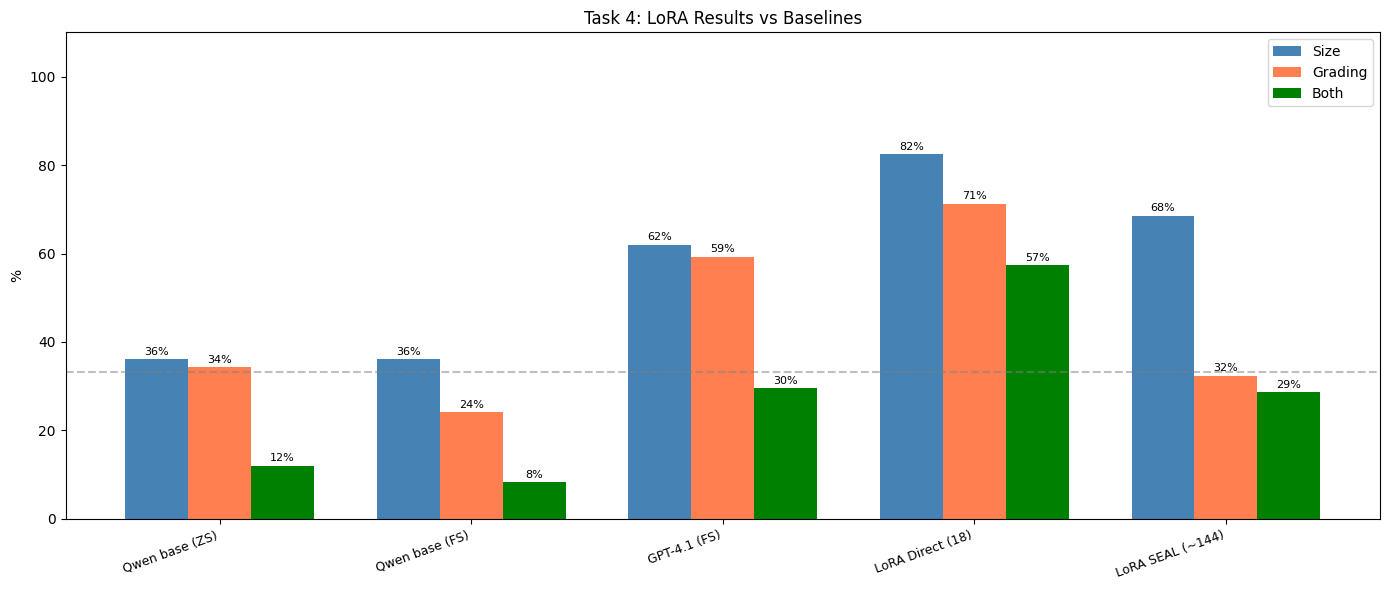

In [34]:
labels = [r['label'] for r in rows]; x = np.arange(len(labels)); w = 0.25
fig, ax = plt.subplots(figsize=(14, 6))
b1 = ax.bar(x-w, [r['size'] for r in rows], w, label='Size', color='steelblue')
b2 = ax.bar(x, [r['grading'] for r in rows], w, label='Grading', color='coral')
b3 = ax.bar(x+w, [r['both'] for r in rows], w, label='Both', color='green')
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('%'); ax.set_ylim(0,110); ax.set_title('Task 4: LoRA Results vs Baselines')
ax.legend(); ax.axhline(y=33.3, color='gray', linestyle='--', alpha=0.5)
for bars in [b1,b2,b3]:
    for bar in bars: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f'{bar.get_height():.0f}%', ha='center', fontsize=8)
plt.tight_layout(); plt.show()


## Save Results

In [36]:
for label, s, results in [('direct', sum_a, r_a), ('augmented', sum_b, r_b)]:
    fname = f'results_{label}.json'
    with open(fname, 'w') as f:
        json.dump({'model':MODEL_ID,'adapter':f'lora_{label}','phase':'fine_tuned',
            'total_images':s['n'],'json_validity_pct':s['json'],'size_accuracy_pct':s['size'],
            'grading_accuracy_pct':s['grading'],'both_correct_pct':s['both'],
            'avg_inference_time_s':s['time'],'results':results}, f, indent=2)
    print(f'Saved {fname}')
print(f'\nAdapters: lora_direct/ and lora_augmented/')
print(f'Winner goes to Task 5 for quantization + edge deployment.')


Saved results_direct.json
Saved results_augmented.json

Adapters: lora_direct/ and lora_augmented/
Winner goes to Task 5 for quantization + edge deployment.
